# EDA



In [2]:
!pip install plotly



In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import plotly.express as px

In [5]:
ruta = r'C:\Maestria\Tercer_semestre\Machine_learning\mitbih_train.csv'
df = pd.read_csv(ruta, header=None) 
df.rename(columns={187:"label"}, inplace=True) #renombrar la columna de label
print("Dimensiones del dataset:", df.shape)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

Dimensiones del dataset: (109446, 188)


El dataset en analisis consta de 188 variables y en su conjunto de entrenamiento de 109446 datos.
El conjunt de Test se tiene en un dataset diferente y no sera objeto de estudio en este EDA para que sea unicamente usado despues de entrenar el modelo. 

# ECG Heartbeat Categorization Dataset

Este conjunto de datos se compone de dos colecciones de señales de latidos cardíacos derivadas de dos conjuntos de datos famosos en la clasificación de latidos cardíacos, el MIT-BIH Arrhythmia Dataset y The PTB Diagnostic ECG Database. El número de muestras en ambas colecciones es lo suficientemente grande como para entrenar incluso una red neuronal profunda.
Las señales corresponden a formas de electrocardiogramas (ECG) de latidos cardíacos para el caso normal y los casos afectados por diferentes arritmias e infarto de miocardio. Estas señales se preprocesan y segmentan, correspondiendo cada segmento a un latido cardíaco.

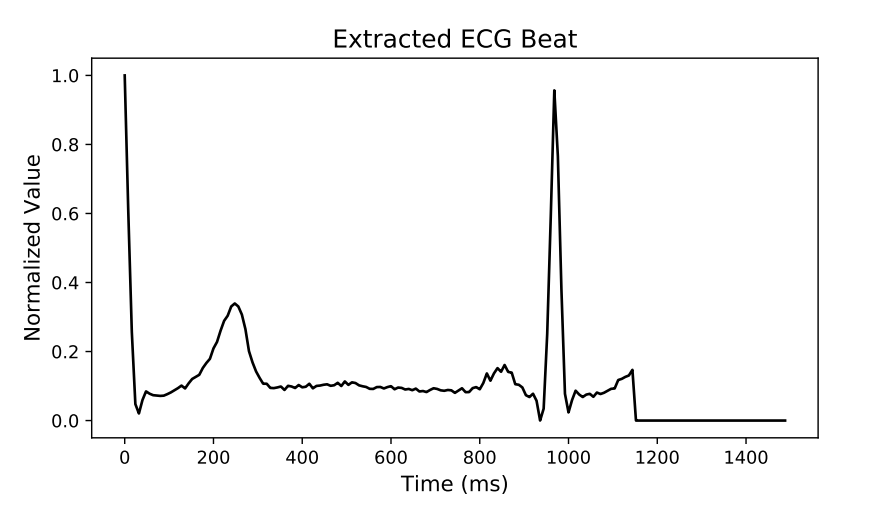


Las labels son: ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]

N: Latidos normales y bloqueos

S: Latidos supraventriculares anormales

V: Latidos ventriculares anormales

F: Latidos fusionados

Q: Latidos artificiales o no clasificados

Nota: Para entender los datos podemos ver el siguiente paper: https://www.kaggle.com/datasets/shayanfazeli/heartbeat

### Resumen estadistico

El dataset consta de 188 columnunas y en la tabla continua podemos ver las metricas estadisticas mas representativas para cada una de esas variables


In [7]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,label
count,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,...,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000,109446.000000
mean,0.891170,0.758910,0.424502,0.219602,0.201237,0.210297,0.205606,0.201615,0.198480,0.196610,...,0.004937,0.004568,0.004236,0.003914,0.003673,0.003469,0.003210,0.002956,0.002835,0.473439
std,0.239656,0.221189,0.227562,0.207249,0.177191,0.171965,0.178374,0.177021,0.171469,0.168028,...,0.043951,0.042110,0.040469,0.038801,0.037466,0.036553,0.035014,0.033414,0.032619,1.143232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.922000,0.683000,0.251000,0.048900,0.082400,0.088300,0.073200,0.066100,0.064900,0.068600,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.991000,0.827000,0.430000,0.166000,0.148000,0.159000,0.145000,0.144000,0.150000,0.149000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.911000,0.580000,0.343000,0.259000,0.287000,0.298000,0.295000,0.291000,0.283000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000


####  Revisión de valores nulos y valores atípicos

En el dataset en estudio no se cuenta con valores nulos 

In [ ]:
df.isnull().sum(axis=0).describe() # Ver si existen valores nulos



count    188.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
dtype: float64

In [37]:
print("\nValores máximos y mínimos de las señales:")
print(f"Máximo: {X.values.max()}, Mínimo: {X.values.min()}")


Valores máximos y mínimos de las señales:
Máximo: 1.0, Mínimo: 0.0


### Balance de clases y KDE de Amplitudes por Clase




In [29]:
df["label"].value_counts()

label
0.0    90589
4.0     8039
2.0     7236
1.0     2779
3.0      803
Name: count, dtype: int64

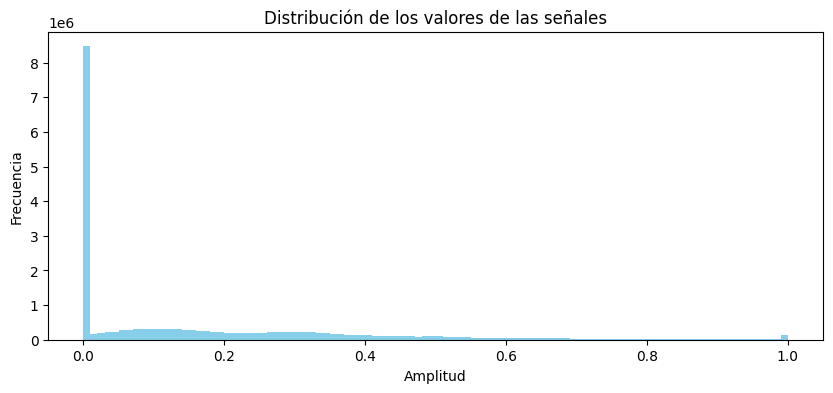

In [34]:
# Histograma de todos los valores de señales (con flatten)
plt.figure(figsize=(10, 4))
plt.hist(X.values.flatten(), bins=100, color='skyblue')
plt.title("Distribución de los valores de las señales")
plt.xlabel("Amplitud")
plt.ylabel("Frecuencia")
plt.show()

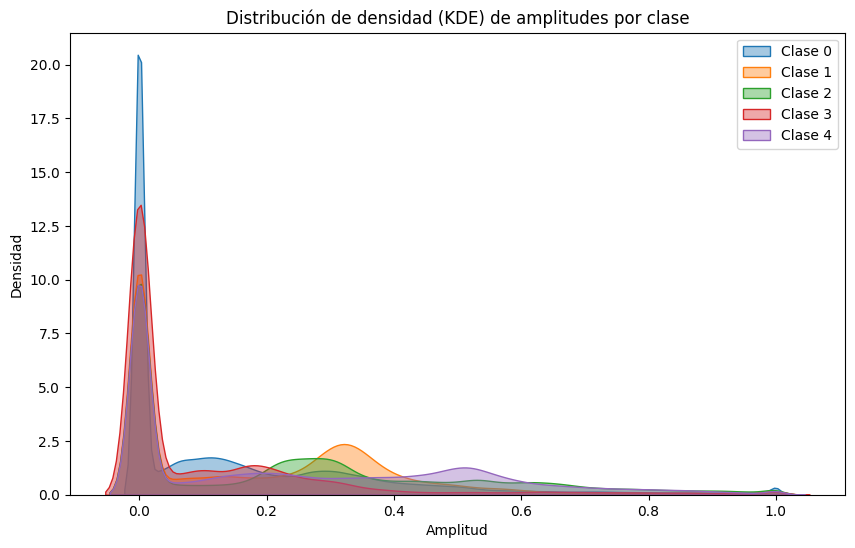

In [20]:
clases = sorted(y.unique())
plt.figure(figsize=(10, 6))
for clase in clases:
    sns.kdeplot(X[y == clase].values.flatten(), label=f'Clase {int(clase)}', fill=True, alpha=0.4)

plt.title("Distribución de densidad (KDE) de amplitudes por clase")
plt.xlabel("Amplitud")
plt.ylabel("Densidad")
plt.legend()
plt.show()

Evidentemente se puede asegurar que Hay un fuerte desbalance de clases, la clase 0.0 domina completamente el dataset y la clase 3.0 tiene menos del 1% de las muestras lo cual nos obligara a usar tecnicas de balanceo para un correcto entrenamiento del modelo.


KDE significa Kernel Density Estimation (Estimación de Densidad por Núcleo). Es una técnica no paramétrica que estima la función de densidad de probabilidad de una variable aleatoria, a partir de una muestra. 
Me permite sugerir aplicar técnicas de reducción de dimensionalidad (PCA, t-SNE) para ver si las clases son separables en base a amplitudes y usar esta información para diseñar estrategias de preprocesamiento o extracción de características.

### Visualización de ejemplos por clase

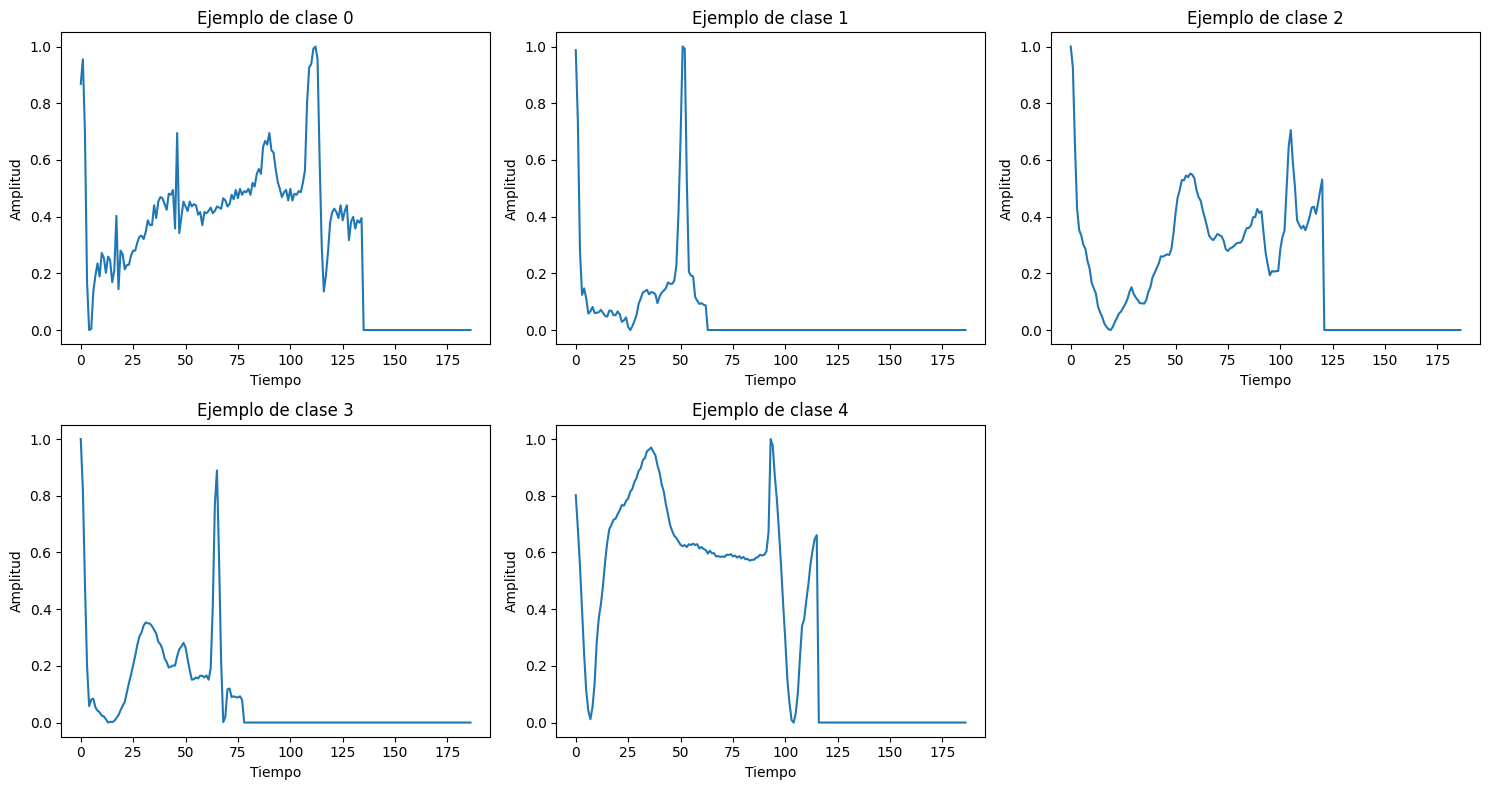

In [ ]:
clases = y.unique()

plt.figure(figsize=(15, 8))
for i, clase in enumerate(sorted(clases)):
    idx = y[y == clase].sample(1).index[0]  
    señal = X.iloc[idx]
    plt.subplot(2, 3, i + 1)
    plt.plot(señal.values)
    plt.title(f"Ejemplo de clase {int(clase)}")
    plt.xlabel("Tiempo")
    plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()


### Estadísticas descriptivas


In [32]:

print("\nEstadísticas de las señales:")
print(X.describe().T[['mean', 'std', 'min', 'max']])



Estadísticas de las señales:
         mean       std  min  max
0    0.891170  0.239656  0.0  1.0
1    0.758910  0.221189  0.0  1.0
2    0.424502  0.227562  0.0  1.0
3    0.219602  0.207249  0.0  1.0
4    0.201237  0.177191  0.0  1.0
..        ...       ...  ...  ...
182  0.003673  0.037466  0.0  1.0
183  0.003469  0.036553  0.0  1.0
184  0.003210  0.035014  0.0  1.0
185  0.002956  0.033414  0.0  1.0
186  0.002835  0.032619  0.0  1.0

[187 rows x 4 columns]


Obtenemos el resumen estadístico por variable.
Los valores se encuentra contenidos entre 0 y 1. 
De los datos podemos inferir que la actividad más importante ocurre al principio o en el medio de la señal. Al final de muchas señales parece ser plano o sin mucha información, esto también lo puedes confirmar con la energía o KDE, revisado anteriormente.

### Señales Extremas Energía máxima y mínima

Evaluación de diversidad en las señales
Las señales más energéticas pueden estar asociadas a latidos más violentos o anormales.
Las señales con baja energía pueden representar latidos débiles o inusuales.
Puede ayudarte a entender el rango de comportamiento cardíaco en el dataset.

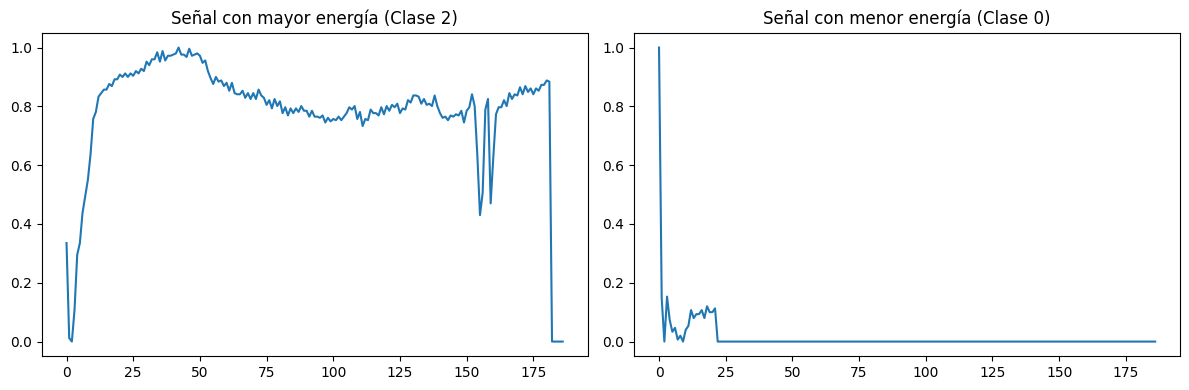

In [17]:
energia = X.apply(lambda x: np.sum(x**2), axis=1)
idx_max = energia.idxmax()
idx_min = energia.idxmin()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(X.iloc[idx_max])
plt.title(f"Señal con mayor energía (Clase {int(y[idx_max])})")

plt.subplot(1, 2, 2)
plt.plot(X.iloc[idx_min])
plt.title(f"Señal con menor energía (Clase {int(y[idx_min])})")
plt.tight_layout()
plt.show()


### CORRELACIONES LINEALES ENTRE VARIABLES

Procedemos inicialmente a realizar una validacion de correlaciones lineales entre las variables de nuestro dataset.

In [5]:
correlations = df.corr()

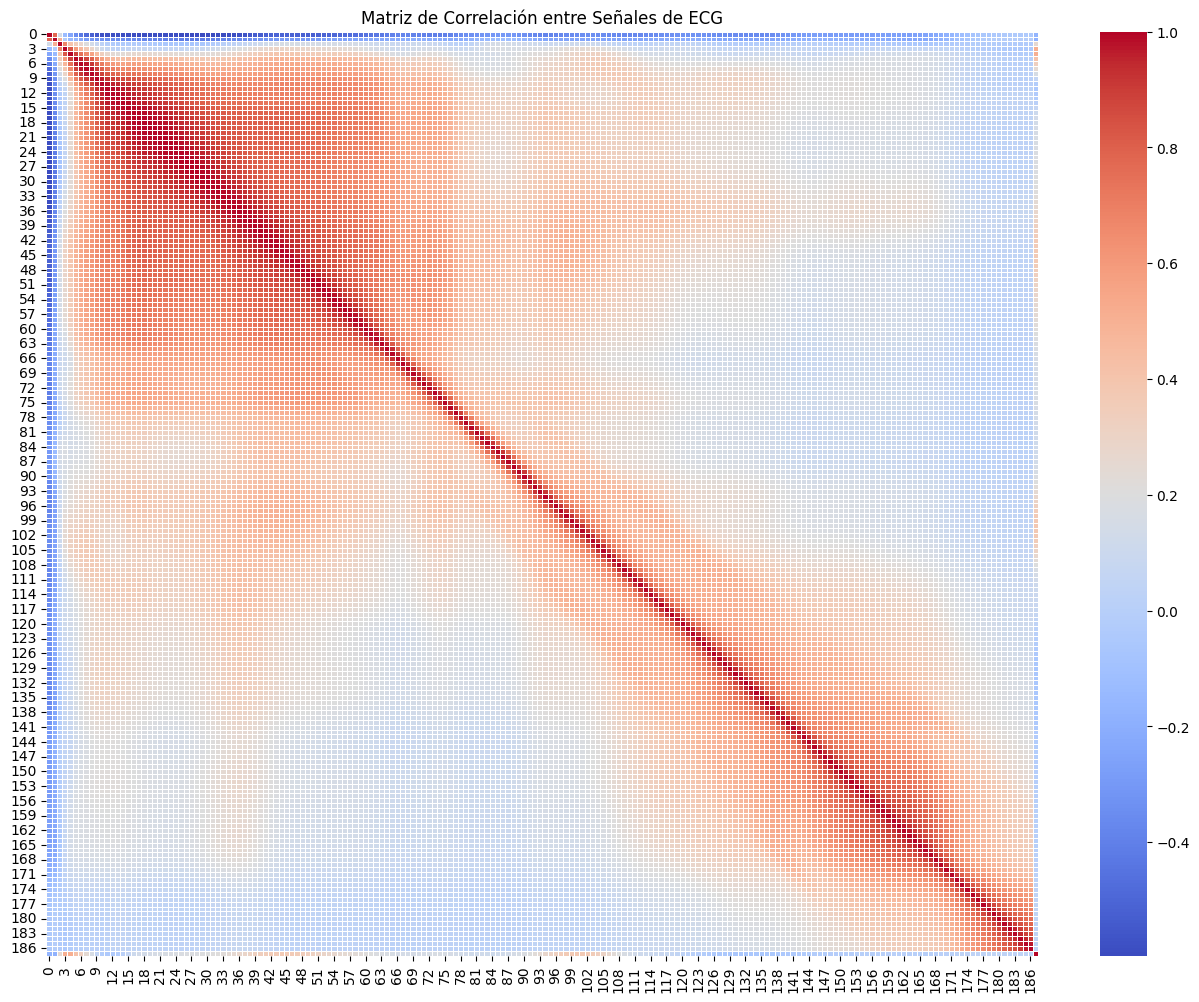

In [6]:
plt.figure(figsize=(16, 12))
sns.heatmap(correlations, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación entre Señales de ECG")
plt.show()

In [7]:
correlations["label"].sort_values(ascending=False).head(15)

label    1.000000
3        0.509593
4        0.509318
5        0.409581
100      0.378121
99       0.375792
101      0.374241
102      0.368043
98       0.366139
44       0.365019
45       0.364287
43       0.363034
46       0.359995
42       0.358139
103      0.352987
Name: label, dtype: float64

Esto es una forma de feature selection básica, para identificar qué variables tienen mayor relación con la clase.
Se puede infereir viendo el mapa de calor que hay segmentos específicos de la señal ECG donde ocurren características distintivas de cada clase.
Ahora procederemos con un nuevo Dataset solo con estas columnas top.

In [10]:
top_features = [3, 4, 5, 100, 99, 101, 102, 98, 44, 45, 43, 46, 42, 103, 'label']
df_top = df[top_features].copy()
df_top.columns = [str(col) for col in df_top.columns]

corr_matrix = df_top.corr()

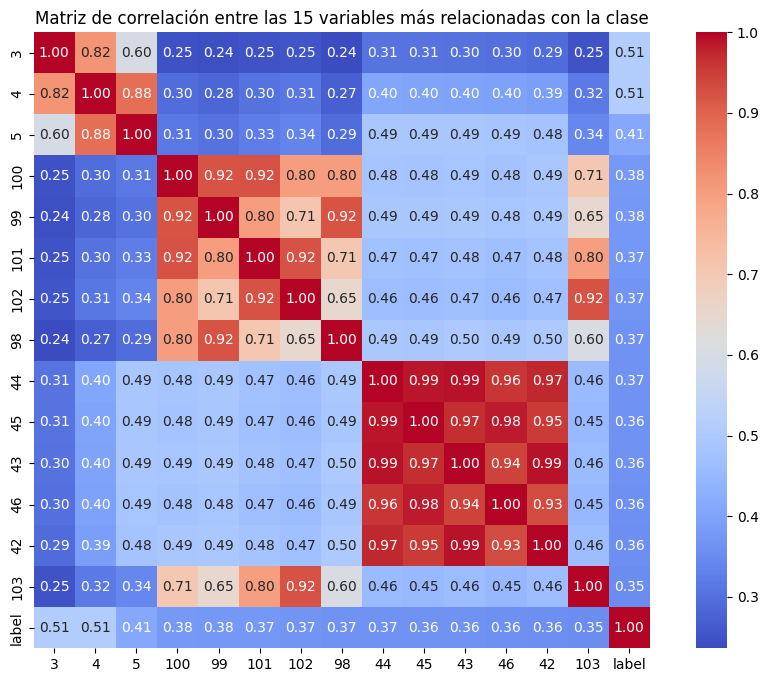

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Matriz de correlación entre las 15 variables más relacionadas con la clase")
plt.show()

En analiis de correlacion lineal solo entre las variables mas correlacionadas linealmente nos permite inferir lo siguiente:
Variables 44, 45, 43, 46, 42 tienen correlaciones muy altas entre sí. Esta informacion nos daria indicio de poder hacer una reducion de la dimensionalidad manteniendo solo una o dos de ellas sin perder mucha información.

In [24]:
df.groupby("label")[3].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0.0,90589.0,0.177809,0.165646,0.00000,0.0388,0.1320,0.2820,1.000
1.0,2779.0,0.091172,0.130588,0.00000,0.0000,0.0326,0.1280,1.000
2.0,7236.0,0.419839,0.283275,0.00000,0.1850,0.3190,0.6700,1.000
3.0,803.0,0.347040,0.191873,0.00000,0.2280,0.3080,0.4075,1.000
4.0,8039.0,0.541981,0.163590,0.00405,0.4270,0.5270,0.6785,0.986


📌 Column: 3
   Skewness: 1.08
   Kurtosis: 0.71


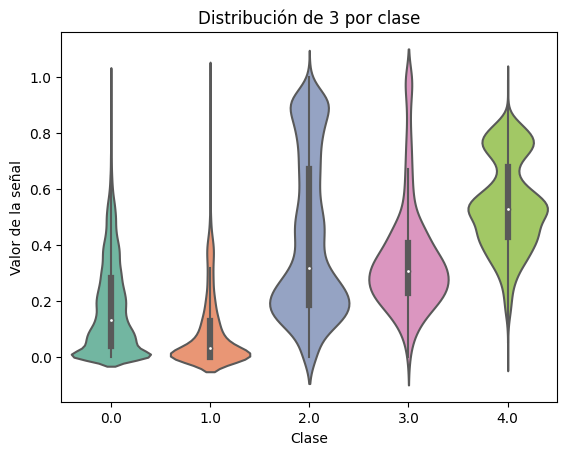

📌 Column: 4
   Skewness: 1.58
   Kurtosis: 2.49


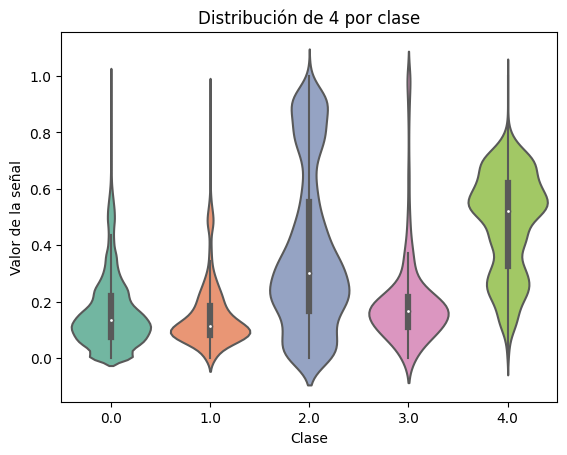

📌 Column: 5
   Skewness: 1.39
   Kurtosis: 1.85


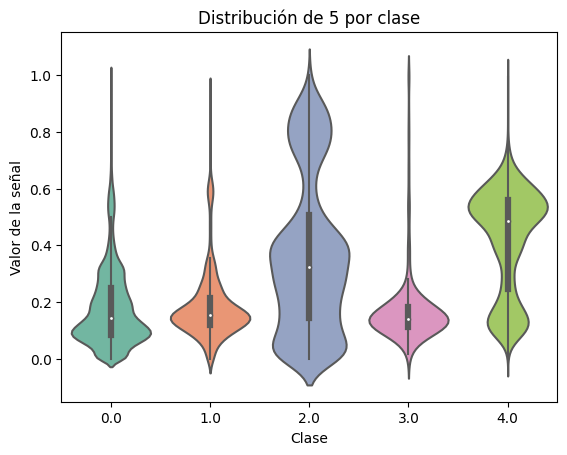

📌 Column: 100
   Skewness: 1.42
   Kurtosis: 1.37


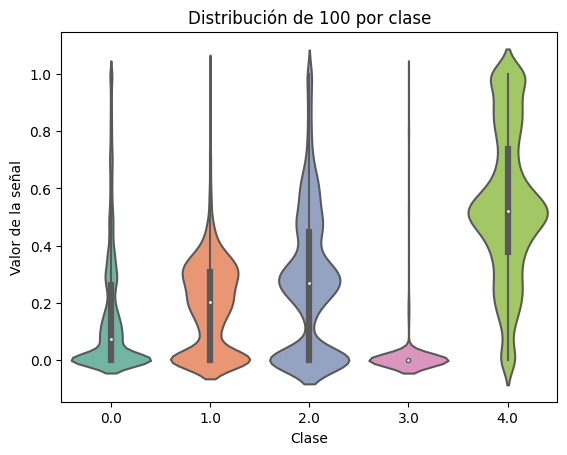

In [52]:
# Seleccionar las 5 variables más correlacionadas con 'label'
columns = correlations["label"].sort_values(ascending=False).head(5).index[1:].values

# Mostrar asimetría, curtosis y gráfico violin para cada una
for col in columns:
    print('📌 Column:', col)
    print('   Skewness:', round(df[col].skew(), 2))
    print('   Kurtosis:', round(df[col].kurtosis(), 2))
    
    # Gráfico tipo violin por clase
    sns.violinplot(data=df, x="label", y=col, palette="Set2", scale="width")
    plt.title(f'Distribución de {col} por clase')
    plt.xlabel("Clase")
    plt.ylabel("Valor de la señal")
    plt.show()

Anteriormente vemos graficamente lo que se visualizo previamente. 
Despues de este analisis de correlacion podriamos proceder con:
* Reducir columnas redundantes- Podria ser con un PCA
* Entrenar un modelo simple solo con estas columnas y comparar con el modelo completo.
* Visualizar la separación de clases en un espacio 2D con t-SNE o PCA.

### Test de Kruskal-Wallis

El test de Kruskal-Wallis es una prueba estadística no paramétrica que se utiliza para determinar si hay diferencias significativas entre las medianas de dos o más grupos independientes.
Es una alternativa al ANOVA cuando no se puede asumir que los datos siguen una distribución normal.


In [42]:
import scipy.stats as stats

classes = df['label'].unique()
col = 3

stat, p_value = stats.kruskal(*(df[df['label'] == c][3] for c in classes))
test_used = "Kruskal-Wallis"

print(f"Test utilizado: {test_used}")
print(f"Estadístico: {stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Diferencia estadísticamente significativa entre las clases.")
else:
    print("No hay evidencia suficiente para afirmar diferencia estadística entre clases.")

Test utilizado: Kruskal-Wallis
Estadístico: 22411.9930, p-valor: 0.0000
Diferencia estadísticamente significativa entre las clases.


En este caso, probamos si el valor de la clase 3 de la señal es estadísticamente diferente entre las distintas clases 
El estadístico de Kruskal-Wallis es muy alto, lo que sugiere una diferencia fuerte.
Como el p-valor es menor a 0.05, se rechaza la hipótesis nula.
Esto significa que existe evidencia estadísticamente significativa de que la variable en la columna 3 toma valores diferentes en al menos una clase.

### PCA

PCA para reducir la dimensionalidad de las señales de ECG, que originalmente tienen 187 variables por señal. Procederemos a proyectar los datos en 3 dimensiones (3 componentes principales)
* Reducción de dimensionalidad: pasas de 187 dimensiones a 3 con pérdida controlada de información.
* Visualizaremos los datos en 3D (scatter 3D por clase).
* Sirve para preprocesamiento de modelos más eficientes y rápidos.


In [44]:
pca3d = PCA(n_components=3)
X_pca3d = pca3d.fit_transform(X)

print(f"Varianza explicada por cada componente: {pca3d.explained_variance_ratio_}")
print(f"Varianza total explicada: {sum(pca3d.explained_variance_ratio_)}")

Varianza explicada por cada componente: [0.43391728 0.10693845 0.07157911]
Varianza total explicada: 0.612434833712368


In [ ]:
df_pca = pd.DataFrame(X_pca3d, columns=["PC1", "PC2", "PC3"])
df_pca["label"] = y

fig = px.scatter_3d(df_pca, x="PC1", y="PC2", z="PC3", color=df_pca["label"].astype(str),
                     title="PCA 3D",
                     labels={"color": "Tipo de Latido"}, opacity=0.7)

fig.show()

Conclusiones:
* PCA está capturando una proporción considerable de la varianza
* El primer componente suele tener mayor poder discriminativo 
* El tercer componente ya explica muy poco

# RNN


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall
from keras_tuner.tuners import RandomSearch
import tensorflow as tf
from keras_tuner import RandomSearch, Objective


In [8]:
# 📥 Cargar datos
ruta = r'C:\Maestria\Tercer_semestre\Machine_learning\mitbih_train.csv'
df = pd.read_csv(ruta, header=None)
df.rename(columns={187: "label"}, inplace=True)
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (109446, 188)


In [9]:
# 🔄 Separar variables y etiquetas
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)

# 🧹 Preparar datos para LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))  # (samples, timesteps=187, features=1)
y_cat = to_categorical(y, num_classes=5)   # One-hot

In [10]:
# 📂 División train/validation
X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y)


In [11]:
# 🧠 Modelo LSTM
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], 1)),
    Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 🛑 EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


Epoch 1/20
1369/1369 [==============================] - 36s 18ms/step - loss: 0.6601 - accuracy: 0.8276 - val_loss: 0.6424 - val_accuracy: 0.8286
Epoch 2/20
1369/1369 [==============================] - 19s 14ms/step - loss: 0.5914 - accuracy: 0.8293 - val_loss: 0.5345 - val_accuracy: 0.8202
Epoch 3/20
1369/1369 [==============================] - 20s 14ms/step - loss: 0.5155 - accuracy: 0.8498 - val_loss: 0.5717 - val_accuracy: 0.8262
Epoch 4/20
1369/1369 [==============================] - 21s 15ms/step - loss: 0.5003 - accuracy: 0.8410 - val_loss: 0.4798 - val_accuracy: 0.8577
Epoch 5/20
1369/1369 [==============================] - 21s 15ms/step - loss: 0.4688 - accuracy: 0.8628 - val_loss: 0.6388 - val_accuracy: 0.8167
Epoch 6/20
1369/1369 [==============================] - 20s 15ms/step - loss: 0.6440 - accuracy: 0.8287 - val_loss: 0.6365 - val_accuracy: 0.8311
Epoch 7/20
1369/1369 [==============================] - 20s 15ms/step - loss: 0.6161 - accuracy: 0.8309 - val_loss: 0.6542 -

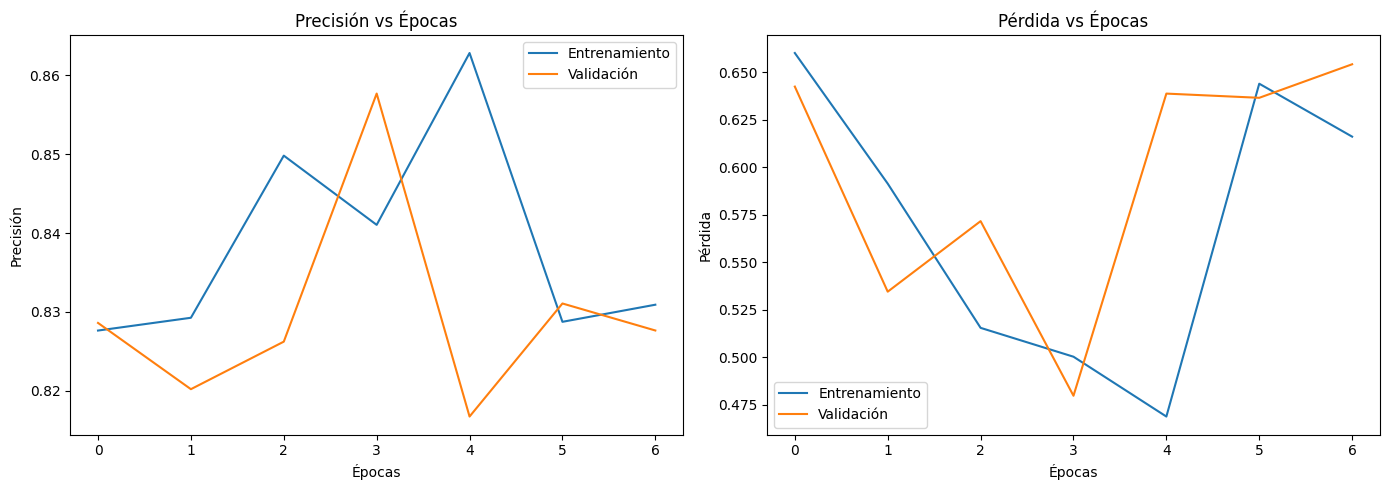

In [12]:
# 🏋️ Entrenar
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# 📊 Gráfica de pérdida y accuracy
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense (Dense)               (None, 5)                 325       
                                                                 
Total params: 17,221
Trainable params: 17,221
Non-trainable params: 0
_________________________________________________________________


In [ ]:
#Cargar datos
ruta = r'C:\Maestria\Tercer_semestre\Machine_learning\mitbih_train.csv'
df = pd.read_csv(ruta, header=None)
df.rename(columns={187: "label"}, inplace=True)

# 🔄 Preprocesamiento
X = df.iloc[:, :-1].values.reshape((-1, 187, 1)).astype(np.float32)
y = to_categorical(df.iloc[:, -1].values.astype(int), num_classes=5)

In [ ]:
#Dividir en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
#DEFINICIÓN DEL MODELO PARA KERAS TUNER
def build_model(hp):
    model = Sequential()
    model.add(LSTM(
        units=hp.Int('lstm_units', 32, 128, step=32),
        input_shape=(187, 1)
    ))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(Dense(
        units=hp.Int('dense_units', 32, 128, step=32),
        activation='relu'
    ))
    model.add(Dense(5, activation='softmax'))
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=[Recall(name='recall')]
    )
    return model

In [29]:
# 🔍 Inicializar tuner con métrica personalizada
tuner = RandomSearch(
    build_model,
    objective=Objective("val_recall", direction="max"),
    max_trials=10,
    executions_per_trial=1,
    directory='kt_lstm',
    project_name='ecg_lstm_recall'
)




In [39]:
early_stop = EarlyStopping(monitor='val_recall', mode='max', patience=3, restore_best_weights=True)

In [ ]:

# 🔍 INICIALIZAR KERAS TUNER
tuner = RandomSearch(
    build_model,
    objective=Objective('val_recall', direction='max'),
    max_trials=10,
    executions_per_trial=1,
    directory='kt_lstm',
    project_name='ecg_lstm_recall'
)



# 🚀 TUNING
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=2
)
# 🏆 MEJORES HIPERPARÁMETROS
best_hps = tuner.get_best_hyperparameters(1)[0]
print("\n✅ Mejores hiperparámetros encontrados:")
print(f"LSTM units: {best_hps.get('lstm_units')}")
print(f"Dense units: {best_hps.get('dense_units')}")
print(f"Dropout: {best_hps.get('dropout')}")
print(f"Learning rate: {best_hps.get('lr')}")

Trial 10 Complete [00h 04m 20s]
val_recall: 0.9343535900115967

Best val_recall So Far: 0.9448606371879578
Total elapsed time: 00h 23m 19s

✅ Mejores hiperparámetros encontrados:
LSTM units: 96
Dense units: 96
Dropout: 0.2
Learning rate: 0.01


Epoch 1/20
1369/1369 [==============================] - 24s 17ms/step - loss: 0.5778 - recall: 0.8175 - accuracy: 0.8358 - val_loss: 0.4241 - val_recall: 0.8658 - val_accuracy: 0.8714
Epoch 2/20
1369/1369 [==============================] - 23s 17ms/step - loss: 0.4021 - recall: 0.8739 - accuracy: 0.8827 - val_loss: 0.3759 - val_recall: 0.8825 - val_accuracy: 0.8880
Epoch 3/20
1369/1369 [==============================] - 23s 17ms/step - loss: 0.3569 - recall: 0.8902 - accuracy: 0.9005 - val_loss: 0.3303 - val_recall: 0.9077 - val_accuracy: 0.9111
Epoch 4/20
1369/1369 [==============================] - 23s 17ms/step - loss: 0.3232 - recall: 0.9114 - accuracy: 0.9163 - val_loss: 0.2894 - val_recall: 0.9226 - val_accuracy: 0.9245
Epoch 5/20
1369/1369 [==============================] - 23s 17ms/step - loss: 0.2984 - recall: 0.9238 - accuracy: 0.9262 - val_loss: 0.2813 - val_recall: 0.9288 - val_accuracy: 0.9300
Epoch 6/20
1369/1369 [==============================] - 23s 17ms/step - loss: 0.

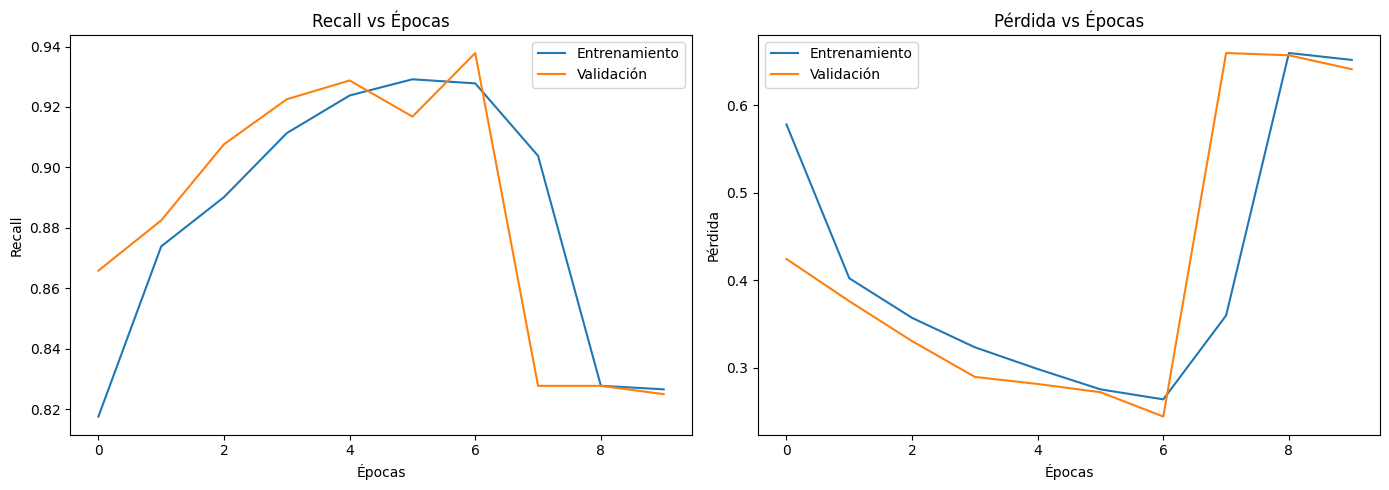

In [40]:

# 🔁 REENTRENAMIENTO FINAL CON EL MEJOR MODELO
model = Sequential([
    LSTM(best_hps.get('lstm_units'), input_shape=(187, 1)),
    Dropout(best_hps.get('dropout')),
    Dense(best_hps.get('dense_units'), activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=best_hps.get('lr')),
    loss='categorical_crossentropy',
    metrics=[Recall(name='recall'), 'accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# 💾 GUARDAR MODELO FINAL
model.save("mejor_lstm_afinado.keras")

# 📊 GRÁFICAS DE ENTRENAMIENTO
plt.figure(figsize=(14, 5))

# Recall
plt.subplot(1, 2, 1)
plt.plot(history.history['recall'], label='Entrenamiento')
plt.plot(history.history['val_recall'], label='Validación')
plt.title('Recall vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Recall')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 96)                37632     
                                                                 
 dropout_4 (Dropout)         (None, 96)                0         
                                                                 
 dense_8 (Dense)             (None, 96)                9312      
                                                                 
 dense_9 (Dense)             (None, 5)                 485       
                                                                 
Total params: 47,429
Trainable params: 47,429
Non-trainable params: 0
_________________________________________________________________


# CNN

In [42]:
# 📦 IMPORTS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Recall
from keras_tuner import RandomSearch, Objective
import matplotlib.pyplot as plt

In [43]:
# 📥 CARGA Y PREPARACIÓN
ruta = r'C:\Maestria\Tercer_semestre\Machine_learning\mitbih_train.csv'
df = pd.read_csv(ruta, header=None)
df.rename(columns={187: "label"}, inplace=True)

X = df.iloc[:, :-1].values.reshape((-1, 187, 1)).astype(np.float32)
y = to_categorical(df.iloc[:, -1].values.astype(int), num_classes=5)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [44]:
# 🧠 DEFINICIÓN DEL MODELO CNN PARA KERAS TUNER
def build_model(hp):
    model = Sequential()
    
    model.add(Conv1D(
        filters=hp.Int('filters', 32, 128, step=32),
        kernel_size=hp.Choice('kernel_size', [3, 5, 7]),
        activation='relu',
        input_shape=(187, 1)
    ))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout1', 0.2, 0.5, step=0.1)))
    
    model.add(Conv1D(
        filters=hp.Int('filters2', 32, 128, step=32),
        kernel_size=hp.Choice('kernel_size2', [3, 5]),
        activation='relu'
    ))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout2', 0.2, 0.5, step=0.1)))
    
    model.add(Flatten())
    model.add(Dense(
        units=hp.Int('dense_units', 32, 128, step=32),
        activation='relu'
    ))
    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=[Recall(name='recall'), 'accuracy']
    )
    return model

In [ ]:
# 🔍 TUNER CONFIG
tuner = RandomSearch(
    build_model,
    objective=Objective('val_recall', direction='max'),
    max_trials=10,
    executions_per_trial=1,
    directory='kt_cnn',
    project_name='ecg_cnn_recall'
)

early_stop = EarlyStopping(
    monitor='val_recall',
    mode='max',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [46]:
# 🚀 BÚSQUEDA DE HIPERPARÁMETROS
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=2
)

# ✅ MEJORES HIPERPARÁMETROS
best_hps = tuner.get_best_hyperparameters(1)[0]
print("\n✅ Mejores hiperparámetros encontrados:")
print(f"Filters: {best_hps.get('filters')}")
print(f"Kernel size: {best_hps.get('kernel_size')}")
print(f"Dense units: {best_hps.get('dense_units')}")
print(f"Dropout: {best_hps.get('dropout1')}, {best_hps.get('dropout2')}")
print(f"Learning rate: {best_hps.get('lr')}")

Trial 10 Complete [00h 00m 54s]
val_recall: 0.9804019927978516

Best val_recall So Far: 0.9845134615898132
Total elapsed time: 00h 09m 00s

✅ Mejores hiperparámetros encontrados:
Filters: 128
Kernel size: 3
Dense units: 128
Dropout: 0.2, 0.2
Learning rate: 0.001


Epoch 1/20
1369/1369 [==============================] - 7s 5ms/step - loss: 0.2114 - recall: 0.9346 - accuracy: 0.9410 - val_loss: 0.1305 - val_recall: 0.9608 - val_accuracy: 0.9638
Epoch 2/20
1369/1369 [==============================] - 6s 4ms/step - loss: 0.1151 - recall: 0.9666 - accuracy: 0.9684 - val_loss: 0.0924 - val_recall: 0.9740 - val_accuracy: 0.9754
Epoch 3/20
1369/1369 [==============================] - 6s 4ms/step - loss: 0.0901 - recall: 0.9731 - accuracy: 0.9745 - val_loss: 0.0824 - val_recall: 0.9761 - val_accuracy: 0.9767
Epoch 4/20
1369/1369 [==============================] - 6s 4ms/step - loss: 0.0759 - recall: 0.9766 - accuracy: 0.9777 - val_loss: 0.0746 - val_recall: 0.9780 - val_accuracy: 0.9791
Epoch 5/20
1369/1369 [==============================] - 6s 4ms/step - loss: 0.0644 - recall: 0.9801 - accuracy: 0.9810 - val_loss: 0.0751 - val_recall: 0.9795 - val_accuracy: 0.9800
Epoch 6/20
1369/1369 [==============================] - 6s 4ms/step - loss: 0.0585 - recal

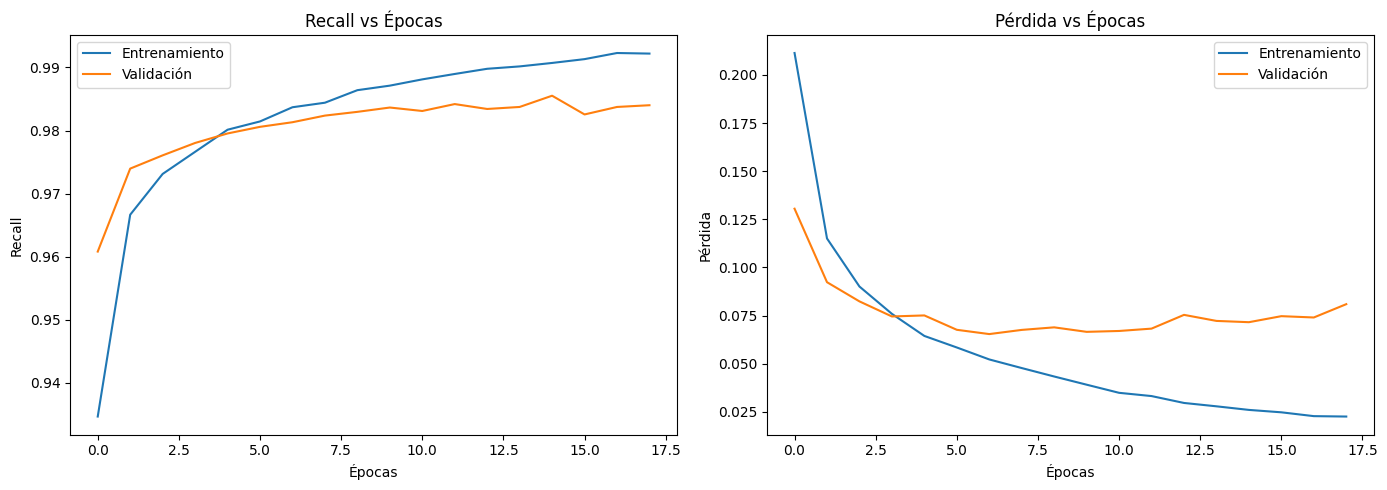

In [47]:
# 🔁 REENTRENAMIENTO CON MEJOR MODELO
model = build_model(best_hps)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# 💾 GUARDAR MODELO
model.save("mejor_cnn_afinado.keras")

# 📊 GRAFICAR RECALL Y PÉRDIDA
plt.figure(figsize=(14, 5))

# Recall
plt.subplot(1, 2, 1)
plt.plot(history.history['recall'], label='Entrenamiento')
plt.plot(history.history['val_recall'], label='Validación')
plt.title('Recall vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Recall')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

In [48]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 185, 128)          512       
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 92, 128)          0         
 1D)                                                             
                                                                 
 dropout_2 (Dropout)         (None, 92, 128)           0         
                                                                 
 conv1d_3 (Conv1D)           (None, 88, 128)           82048     
                                                                 
 max_pooling1d_3 (MaxPooling  (None, 44, 128)          0         
 1D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 44, 128)          

# AUTOENCODERS

In [21]:
# 📦 Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv1D, MaxPooling1D, UpSampling1D, Cropping1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [4]:
# 📥 Cargar datos
ruta = r'C:\Maestria\Tercer_semestre\Machine_learning\mitbih_train.csv'
df = pd.read_csv(ruta, header=None)
df.rename(columns={187: "label"}, inplace=True)

X = df.iloc[:, :-1].values.astype(np.float32)
y = to_categorical(df.iloc[:, -1].values.astype(int), num_classes=5)

In [5]:
# ⚙️ Normalizar y reshaping
X = X / np.max(X)  # Normalización
X = X.reshape((X.shape[0], X.shape[1], 1))  # Para usar Conv1D

# 📂 Dividir en train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
# 🧠 Construir AUTOENCODER
input_ecg = Input(shape=(187, 1))

# Codificador
x = Conv1D(32, 3, activation='relu', padding='same')(input_ecg)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(16, 3, activation='relu', padding='same')(x)
encoded = MaxPooling1D(2, padding='same')(x)  # (47, 16)

# Decodificador
x = Conv1D(16, 3, activation='relu', padding='same')(encoded)
x = UpSampling1D(2)(x)
x = Conv1D(32, 3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
x = Conv1D(1, 3, activation='sigmoid', padding='same')(x)
x = Cropping1D(cropping=(0, 1))(x)  # 🛠 Solución: Recortar 1 para que quede (187, 1)
decoded = x

In [7]:
# 🔧 Modelo autoencoder
autoencoder = Model(input_ecg, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 187, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 187, 32)           128       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 94, 32)           0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 94, 16)            1552      
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 47, 16)           0         
 1D)                                                             
                                                                 
 conv1d_2 (Conv1D)           (None, 47, 16)            784   

Total params: 4,129
Trainable params: 4,129
Non-trainable params: 0
_________________________________________________________________


In [59]:
# 🏋️ Entrenar autoencoder
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_ae = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
685/685 [==============================] - 5s 6ms/step - loss: 0.0076 - val_loss: 7.1532e-04
Epoch 2/20
685/685 [==============================] - 4s 6ms/step - loss: 5.1302e-04 - val_loss: 4.0755e-04
Epoch 3/20
685/685 [==============================] - 4s 6ms/step - loss: 3.5906e-04 - val_loss: 3.2585e-04
Epoch 4/20
685/685 [==============================] - 4s 6ms/step - loss: 2.9088e-04 - val_loss: 2.9254e-04
Epoch 5/20
685/685 [==============================] - 4s 6ms/step - loss: 2.6015e-04 - val_loss: 2.6236e-04
Epoch 6/20
685/685 [==============================] - 4s 6ms/step - loss: 2.3856e-04 - val_loss: 2.2921e-04
Epoch 7/20
685/685 [==============================] - 4s 6ms/step - loss: 2.2186e-04 - val_loss: 2.1290e-04
Epoch 8/20
685/685 [==============================] - 4s 6ms/step - loss: 2.0879e-04 - val_loss: 2.0065e-04
Epoch 9/20
685/685 [==============================] - 4s 6ms/step - loss: 1.9723e-04 - val_loss: 1.9028e-04
Epoch 10/20
685/685 [===========

In [8]:
# ✂️ Extraer codificador
encoder = Model(input_ecg, encoded)

685/685 [==============================] - 1s 893us/step
Epoch 1/20
1369/1369 [==============================] - 4s 3ms/step - loss: 0.3068 - recall: 0.8955 - accuracy: 0.9134 - val_loss: 0.1759 - val_recall: 0.9490 - val_accuracy: 0.9519
Epoch 2/20
1369/1369 [==============================] - 4s 3ms/step - loss: 0.1658 - recall: 0.9503 - accuracy: 0.9544 - val_loss: 0.1326 - val_recall: 0.9629 - val_accuracy: 0.9646
Epoch 3/20
1369/1369 [==============================] - 4s 3ms/step - loss: 0.1387 - recall: 0.9595 - accuracy: 0.9624 - val_loss: 0.1173 - val_recall: 0.9657 - val_accuracy: 0.9676
Epoch 4/20
1369/1369 [==============================] - 4s 3ms/step - loss: 0.1231 - recall: 0.9641 - accuracy: 0.9664 - val_loss: 0.1063 - val_recall: 0.9695 - val_accuracy: 0.9706
Epoch 5/20
1369/1369 [==============================] - 4s 3ms/step - loss: 0.1148 - recall: 0.9666 - accuracy: 0.9687 - val_loss: 0.1029 - val_recall: 0.9697 - val_accuracy: 0.9714
Epoch 6/20
1369/1369 [===========

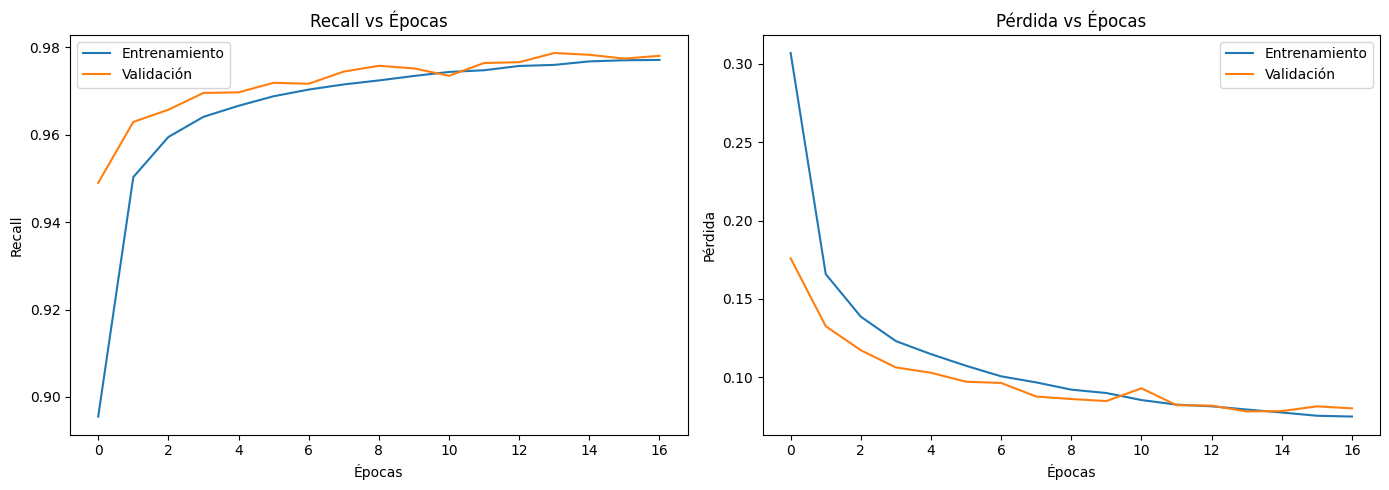

In [17]:


# 📥 Extraer representaciones latentes
X_train_encoded = encoder.predict(X_train)
X_val_encoded = encoder.predict(X_val)

# 🔄 Aplanar codificaciones para clasificación
X_train_flat = X_train_encoded.reshape((X_train_encoded.shape[0], -1))
X_val_flat = X_val_encoded.reshape((X_val_encoded.shape[0], -1))

# 🧠 Modelo de clasificación
classifier = Sequential()
classifier.add(Dense(128, activation='relu', input_shape=(X_train_flat.shape[1],)))
classifier.add(Dropout(0.3))
classifier.add(Dense(64, activation='relu'))
classifier.add(Dense(5, activation='softmax'))

classifier.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[Recall(name='recall'), 'accuracy']
)

# 🛑 Early stopping para clasificación
early_stop_cls = EarlyStopping(monitor='val_recall', mode='max', patience=3, restore_best_weights=True)

# 🚀 Entrenamiento del clasificador
history_cls = classifier.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_cls],
    verbose=1
)

classifier.save("clasificador_autoencoder.keras")

# 📊 Gráficas
plt.figure(figsize=(14, 5))

# Recall
plt.subplot(1, 2, 1)
plt.plot(history_cls.history['recall'], label='Entrenamiento')
plt.plot(history_cls.history['val_recall'], label='Validación')
plt.title('Recall vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Recall')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_cls.history['loss'], label='Entrenamiento')
plt.plot(history_cls.history['val_loss'], label='Validación')
plt.title('Pérdida vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
classifier.summary()
autoencoder.summary()
encoder.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               96384     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 5)                 325       
                                                                 
Total params: 104,965
Trainable params: 104,965
Non-trainable params: 0
_________________________________________________________________
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None

### Revision en Test de cada modelo

In [15]:
from tensorflow.keras.models import load_model

In [10]:
ruta_test = r'C:\Maestria\Tercer_semestre\Machine_learning\mitbih_test.csv'
df_test = pd.read_csv(ruta_test, header=None)
df_test.rename(columns={187: "label"}, inplace=True)

# Separar X e y
X_test = df_test.iloc[:, :-1].values.astype(np.float32)
y_test = pd.get_dummies(df_test.iloc[:, -1].values.astype(int)).values  # one-hot

# Normalizar y reshape (para LSTM y CNN)
X_test_scaled = X_test / np.max(X_test)
X_test_seq = X_test_scaled.reshape((-1, 187, 1))

### Evaluación LSTM

In [22]:
# Cargar modelo previamente guardado
model_lstm = load_model("mejor_lstm_afinado.keras")

# Evaluar
loss_lstm, recall_lstm, acc_lstm = model_lstm.evaluate(X_test_seq, y_test, verbose=0)
print(f"[LSTM] Recall: {recall_lstm:.4f} - Accuracy: {acc_lstm:.4f} - Loss: {loss_lstm:.4f}")

[LSTM] Recall: 0.9369 - Accuracy: 0.9387 - Loss: 0.2490


### Evaluación CNN

In [5]:
model_cnn = load_model("mejor_cnn_afinado.keras")

# Evaluar
loss_cnn, recall_cnn, acc_cnn = model_cnn.evaluate(X_test_seq, y_test, verbose=0)
print(f"[CNN] Recall: {recall_cnn:.4f} - Accuracy: {acc_cnn:.4f} - Loss: {loss_cnn:.4f}")


[CNN] Recall: 0.9926 - Accuracy: 0.9930 - Loss: 0.0314


### Evaluación Autoencoder + Clasificador

In [19]:


# Obtener codificaciones
X_test_encoded = encoder.predict(X_test_seq)
X_test_flat = X_test_encoded.reshape((X_test_encoded.shape[0], -1))

# Evaluar
loss_ae, recall_ae, acc_ae = classifier.evaluate(X_test_flat, y_test, verbose=0)
print(f"[Autoencoder] Recall: {recall_ae:.4f} - Accuracy: {acc_ae:.4f} - Loss: {loss_ae:.4f}")


685/685 [==============================] - 1s 812us/step
[Autoencoder] Recall: 0.9795 - Accuracy: 0.9804 - Loss: 0.0694
